# Filter Design MCD
## Intoduction
This notebook is about creating a behavorial model of a second order analog filter, also know as biquad. There are multiple different approximations, like butterworth, tschebychov or cauer, and way to implement these approximation in real world applications. This notebook will focused on implementing a butterworth high- and lowpass filter with the Sellen-key Implementation and later the Linkwitz-Riley-crossover.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

## Parameters of the Filter

In [14]:
fc = 0.15*10**3 # Cutoff Frequency in Hz
Q0 = 0.5 #1/np.sqrt(2)
fs = 100*10**3 # Sampling Frequency, if needed
ws = 2*np.pi*fs
rp = 3 # maximum passband ripple in dB
rs = 10 # minimum stopband attenuation in dB
N = 2 # Filter order

wc = 2*np.pi*fc
wc_norm = wc/ws

## Butterworth Approximation

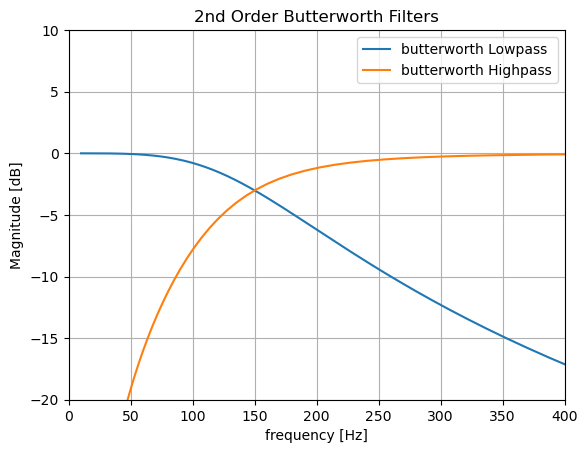

In [20]:
b_butt_lp, a_butt_lp = signal.butter(N,wc_norm,'low',analog = True)
w_butt_lp, mag_butt_lp = signal.freqs(b_butt_lp, a_butt_lp)
mag_dB_butt_lp = 20*np.log10(abs(mag_butt_lp))

b_butt_hp, a_butt_hp = signal.butter(N,wc_norm,'high',analog = True)
w_butt_hp, mag_butt_hp = signal.freqs(b_butt_hp, a_butt_hp, )
mag_dB_butt_hp = 20*np.log10(abs(mag_butt_hp))


plt.plot(w_butt_lp*fs,mag_dB_butt_lp,label="butterworth Lowpass")
plt.plot(w_butt_hp*fs,mag_dB_butt_hp,label="butterworth Highpass")
plt.ylabel("Magnitude [dB]")
plt.xlabel("frequency [Hz]")
plt.title("2nd Order Butterworth Filters")
plt.ylim([-20,10])
plt.xlim([0,400])
plt.grid()
plt.legend()
plt.show()

The plot shows the butterworth approximation for High- and Lowpassfilter.

## Sellen-Key Implementation
The Sellen-Key Implementation can be used to implement second-order active filters with only one opamp.


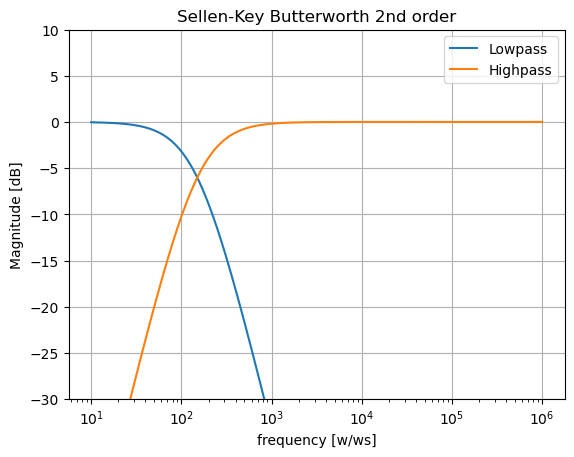

In [26]:
w0 = wc_norm
b_lp_sellen= np.array([0,0,w0**2])
a_sellen = [1, w0/Q0, w0**2]

w_lp_sellen, mag_lp_sellen = signal.freqs(b_lp_sellen,a_sellen)
mag_lp_sellen_dB = 20*np.log10(abs(mag_lp_sellen))

b_hp_sellen = np.array([1,0,0])

w_hp_sellen, mag_hp_sellen = signal.freqs(b_hp_sellen,a_sellen)
mag_hp_sellen_dB = 20*np.log10(abs(mag_hp_sellen))

plt.semilogx(w_lp_sellen*fs,mag_lp_sellen_dB,label="Lowpass")
plt.semilogx(w_hp_sellen*fs,mag_hp_sellen_dB,label="Highpass")
plt.ylabel("Magnitude [dB]")
plt.xlabel("frequency [w/ws]")
plt.title("Sellen-Key Butterworth 2nd order")
plt.ylim([-30,10])
#plt.xlim([0,400])
plt.grid()
plt.legend()
plt.show()

## Linkwitz-Riley Crossover
The Linkwitz-Riley Crossover uses two sellen-key filter implementation in parallel and multiplies their output signal togehter.

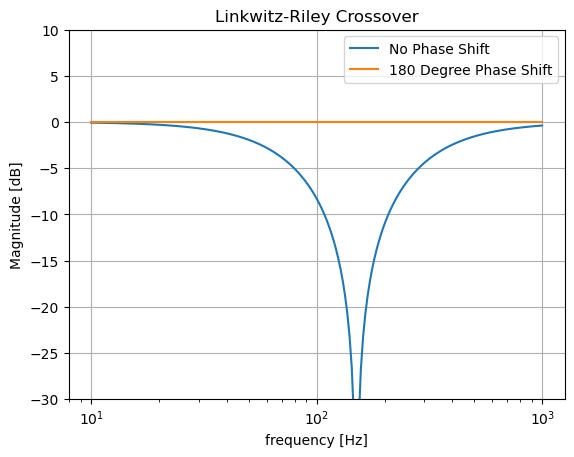

In [27]:
b_linkwitz= b_lp_sellen+b_hp_sellen
a_linkwitz = [1, w0/Q0, w0**2] 

b_linkwitz_shifted= b_lp_sellen+(-1)*b_hp_sellen

w_linkwitz, mag_linkwitz = signal.freqs(b_linkwitz,a_linkwitz)
mag_linkwitz_dB = 20*np.log10(abs(mag_linkwitz))

w_linkwitz_shifted, mag_linkwitz_shifted = signal.freqs(b_linkwitz_shifted,a_linkwitz)
mag_linkwitz_dB_shifted = 20*np.log10(abs(mag_linkwitz_shifted))

plt.semilogx(w_linkwitz*fs,mag_linkwitz_dB,label="No Phase Shift")
plt.semilogx(w_linkwitz_shifted*fs,mag_linkwitz_dB_shifted,label="180 Degree Phase Shift")
plt.ylabel("Magnitude [dB]")
plt.xlabel("frequency [Hz]")
plt.title("Linkwitz-Riley Crossover")
plt.ylim([-30,10])
plt.grid()
plt.legend()
plt.show()

## Full plot of all Magnitude responses of a second order linkwitz riley crossover
The linkwitz-riley-crossover consists of two sellen key filters, one low- and one highpass, and the sum of both. This sum is the crossover. It its important, that the phase of one magnitude response is delayed by 180° or pi, so there is no peak in the crossover magnitude. Overall consist the second oder linkwitz-riley-crossover out of four OTAs/OPamps.

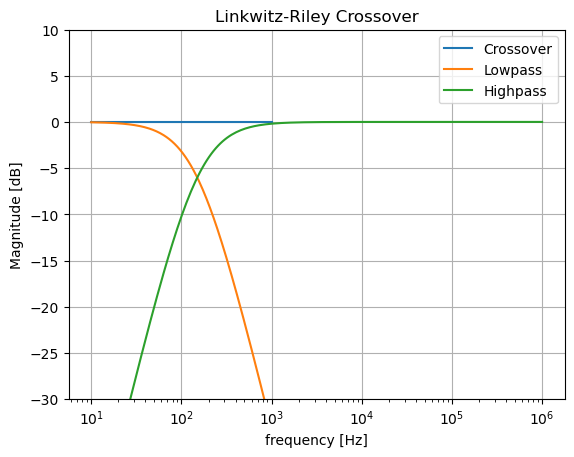

In [28]:
plt.plot(w_linkwitz_shifted*fs,mag_linkwitz_dB_shifted,label="Crossover")
plt.semilogx(w_lp_sellen*fs,mag_lp_sellen_dB,label="Lowpass")
plt.semilogx(w_hp_sellen*fs,mag_hp_sellen_dB,label="Highpass")
plt.ylabel("Magnitude [dB]")
plt.xlabel("frequency [Hz]")
plt.title("Linkwitz-Riley Crossover")
plt.ylim([-30,10])
plt.grid()
plt.legend()
plt.show()